<a href="https://colab.research.google.com/github/Nisha1986/Pupil_Bio_PMP_Analysis/blob/Nisha_Datanalysis/Phased_Methylation_Pattern_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
#import panda
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy.stats import variation, chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
#load data
df = pd.read_csv('/content/PupilBioTest_PMP_revA.csv')

In [31]:
df.shape

(15392183, 13)

In [32]:
#check nan
df.isna().sum()

,0
strand,0
CpG_Coordinates,0
`000,0
`001,0
`010,0
`011,0
`100,0
`101,0
`110,0
`111,0


In [33]:
#find missing values
df.columns

Index(['strand', 'CpG_Coordinates', '`000', '`001', '`010', '`011', '`100',
       '`101', '`110', '`111', 'Sample_ID', 'Replicate', 'Tissue'],
      dtype='object')

In [34]:
df.head()

,strand,CpG_Coordinates,`000,`001,`010,`011,`100,`101,`110,`111,Sample_ID,Replicate,Tissue
0,r,10035:10044:10046,1077,9,0,0,0,0,0,4,1,Rep2,cfDNA
1,r,10035:10044:10053,1086,0,0,0,0,0,0,4,1,Rep2,cfDNA
2,r,10035:10044:10058,1069,17,0,0,0,0,0,4,1,Rep2,cfDNA
3,r,10035:10044:10071,1072,14,0,0,0,0,0,4,1,Rep2,cfDNA
4,r,10035:10044:10075,1086,0,0,0,0,0,0,4,1,Rep2,cfDNA


In [35]:
df['Tissue'].unique()

array(['cfDNA', 'Islet'], dtype=object)

In [36]:
df.groupby('Tissue').size()

,0
Tissue,
Islet,3790100
cfDNA,11602083


In [37]:
# Sum counts across patterns for coverage
pattern_columns = ['`000', '`001', '`010', '`011', '`100', '`101', '`110', '`111']
df['Total_Coverage'] = df[pattern_columns].sum(axis=1)
#Median coverage is used instead of mean because it is less sensitive to extreme values (outliers).
# Group by tissue type and calculate median and CV
coverage_stats = df.groupby('Tissue')['Total_Coverage'].agg(['median', variation]).reset_index()
coverage_stats.columns = ['Tissue', 'Median_Coverage', 'CV_Coverage']

print(coverage_stats)


  Tissue  Median_Coverage  CV_Coverage
0  Islet             84.0     1.136474
1  cfDNA            484.0     1.321131


Islet: The median coverage for Islet tissue is 84.0, indicating that most phased methylation patterns in this tissue have relatively low coverage.
cfDNA: The median coverage for cfDNA is 484.0, much higher than Islet, suggesting that phased methylation patterns in cfDNA tissue have a higher representation or reliability.

Islet: The CV for Islet is 1.136, which means the coverage values for Islet are relatively variable compared to the mean.
cfDNA: The CV for cfDNA is 1.321, indicating even higher variability in coverage for cfDNA tissue than for Islet.


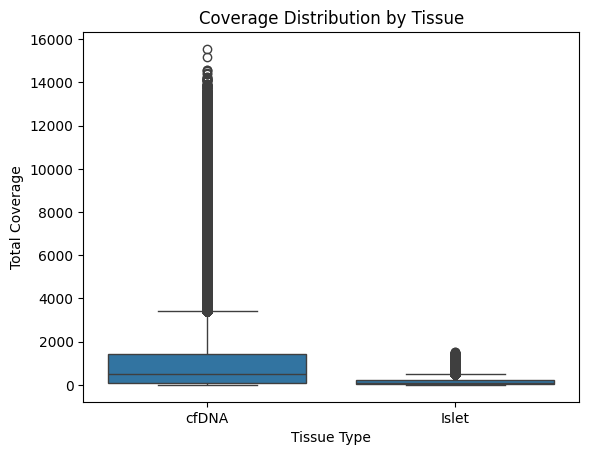

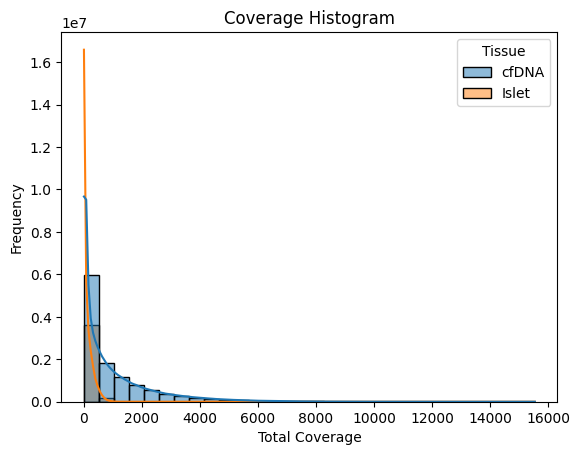

In [38]:
# Boxplot for coverage
sns.boxplot(x='Tissue', y='Total_Coverage', data=df)
plt.title('Coverage Distribution by Tissue')
plt.xlabel('Tissue Type')
plt.ylabel('Total Coverage')
plt.show()

# Histogram for coverage
sns.histplot(df, x='Total_Coverage', hue='Tissue', bins=30, kde=True)
plt.title('Coverage Histogram')
plt.xlabel('Total Coverage')
plt.ylabel('Frequency')
plt.show()


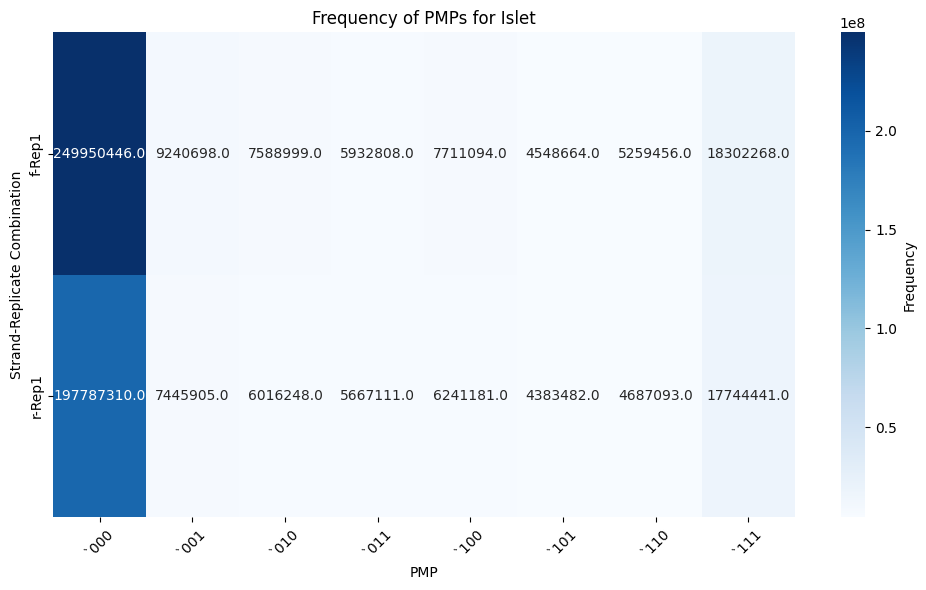

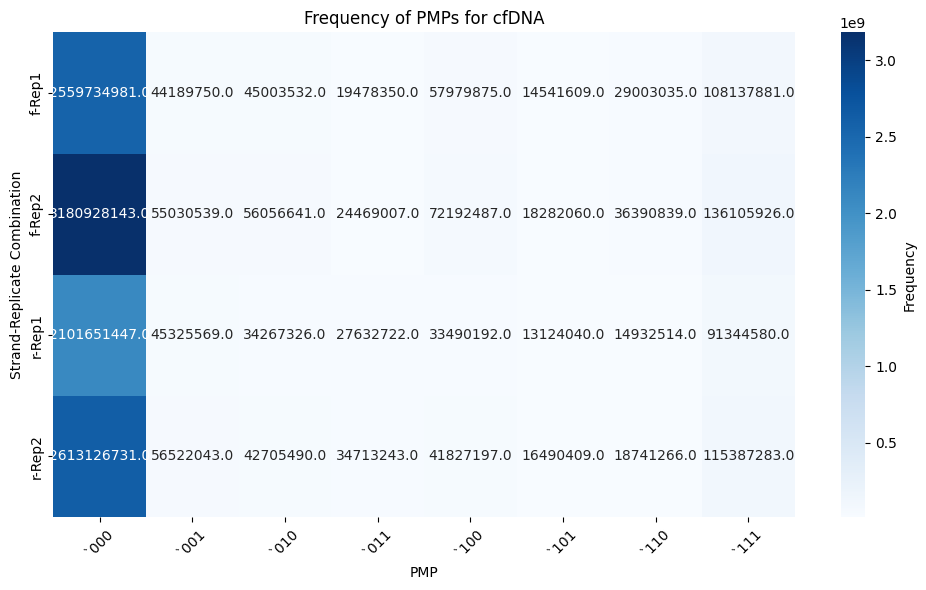

In [39]:
# Define the PMP columns
pmp_columns = ['`000', '`001', '`010', '`011', '`100', '`101', '`110', '`111']

# Group by tissue, strand, and replicate, and sum the PMP counts
grouped_data = df.groupby(['Tissue', 'strand', 'Replicate'])[pmp_columns].sum().reset_index()

# Melt the data for visualization (long format)
melted_data = grouped_data.melt(
    id_vars=['Tissue', 'strand', 'Replicate'],
    value_vars=pmp_columns,
    var_name='PMP',
    value_name='Frequency'
)

# Create a heatmap for each tissue
for tissue in melted_data['Tissue'].unique():
    tissue_data = melted_data[melted_data['Tissue'] == tissue]
    pivot_data = tissue_data.pivot_table(
        index=['strand', 'Replicate'],
        columns='PMP',
        values='Frequency',
        fill_value=0
    )
# Plot the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
    pivot_data,
    cmap='Blues',
    annot=True,
    fmt='.1f',  # Format for one decimal place
    cbar_kws={'label': 'Frequency'}
    )


    plt.title(f'Frequency of PMPs for {tissue}')
    plt.xlabel('PMP')
    plt.ylabel('Strand-Replicate Combination')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [40]:
from scipy.stats import chi2_contingency

# Group data by Tissue and PMP methylation patterns
pmp_data = df[['CpG_Coordinates', 'Tissue']]
print(pmp_data)


            CpG_Coordinates Tissue
0         10035:10044:10046  cfDNA
1         10035:10044:10053  cfDNA
2         10035:10044:10058  cfDNA
3         10035:10044:10071  cfDNA
4         10035:10044:10075  cfDNA
...                     ...    ...
15392178   9998:10121:10133  Islet
15392179   9998:10121:10140  Islet
15392180   9998:10130:10133  Islet
15392181   9998:10130:10140  Islet
15392182   9998:10133:10140  Islet

[15392183 rows x 2 columns]


In [41]:
pmp_data

,CpG_Coordinates,Tissue
0,10035:10044:10046,cfDNA
1,10035:10044:10053,cfDNA
2,10035:10044:10058,cfDNA
3,10035:10044:10071,cfDNA
4,10035:10044:10075,cfDNA
...,...,...
15392178,9998:10121:10133,Islet
15392179,9998:10121:10140,Islet
15392180,9998:10130:10133,Islet
15392181,9998:10130:10140,Islet


In [42]:
# Calculate VRF for each PMP
for pattern in pattern_columns:
    df[f'VRF_{pattern}'] = df[pattern] / df['Total_Coverage']

# Group by tissue and calculate mean VRF
mean_vrf = df.groupby('Tissue')[[f'VRF_{pattern}' for pattern in pattern_columns]].mean().reset_index()

print(mean_vrf)


  Tissue  VRF_`000  VRF_`001  VRF_`010  VRF_`011  VRF_`100  VRF_`101  \
0  Islet  0.844271  0.024049  0.020368  0.014968  0.021763  0.012482   
1  cfDNA  0.907418  0.015772  0.013900  0.007565  0.016336  0.004116   

   VRF_`110  VRF_`111  
0  0.014237  0.047862  
1  0.007432  0.027461  


In [43]:
!pip install lightgbm
!pip install dask[dataframe]


In [44]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
# X: PMP counts (e.g., `000`, `001`, ...)
# y: Tissue labels (e.g., 0 for Islet, 1 for cfDNA)
pattern_columns = ['`000', '`001', '`010', '`011', '`100', '`101', '`110', '`111']
X = df[pattern_columns]
y = df['Tissue'].apply(lambda x: 1 if x == 'cfDNA' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Set LightGBM parameters
params = {
    'objective': 'binary',           # Binary classification
    'boosting_type': 'gbdt',         # Gradient Boosting Decision Trees
    'metric': 'binary_logloss',      # Evaluation metric
    'class_weight': 'balanced',      # Automatically balance class weights
    'learning_rate': 0.05,           # Learning rate
    'num_leaves': 31,                # Maximum number of leaves
    'max_depth': -1,                 # Unlimited depth
    'verbose': -1                    # Suppress output
}

# Define early stopping callback
early_stopping = lgb.early_stopping(stopping_rounds=10)

# Train the LightGBM model
model = lgb.train(
    params,
    train_data,
    num_boost_round=100,             # Total boosting rounds
    valid_sets=[test_data],          # Validation dataset
    valid_names=['valid'],           # Name the validation set
    callbacks=[early_stopping]       # Add the early stopping callbac
)
# Predict on the test set
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)  # Use the best iteration
y_pred = (y_pred_proba > 0.5).astype(int)  # Binary predictions

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")


Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.374649
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.34      0.46   1136742
           1       0.82      0.96      0.88   3480913

    accuracy                           0.81   4617655
   macro avg       0.77      0.65      0.67   4617655
weighted avg       0.80      0.81      0.78   4617655

AUC-ROC: 0.8577
